In [4]:
import matplotlib.pyplot
import numpy as np 
from scipy.optimize import fsolve
import matplotlib.pyplot as plt 
from scipy.special import gamma 
import matplotlib
from tqdm import * 

from src.FDE02solver import *
from src.FDE02gradedsolver import *  

In [5]:
schemes = ["RIIA1" , "RIIA2", "RIIA3"]
Ns = np.asarray([10, 20,40,80,160,320])
gammas = [1,3,5]

# Setting

In [6]:
file01 = 'data/RA_DO/distGamma4_m_102_AAAtol_1.0e-45.csv'
data01 = np.genfromtxt(file01, delimiter=',')
weights01 = data01[0,:]
exponents01 = -data01[1,:] 

file12 = 'data/RA_DO/distGamma3_m_102_AAAtol_1.0e-45.csv'
data12 = np.genfromtxt(file12, delimiter=',')
weights12 = data12[0,:]
exponents12 = -data12[1,:] 

def rhs(t,y): 
    if np.abs(t-1) < 1e-8:
        return 59/3 + (57 *(t - 1))/2 + 401/30 *(t - 1)**2 + 83/36 * (t - 1)**3 - (1291 * (t - 1)**4)/5040 + (191 * (t - 1)**5)/1440
    else: 
        return (6*t**3 + 6*t -4) / np.log(t) + (6-10*t) / np.log(t)**2 + (4*t-4) / np.log(t)**3

def sol(t): 
    return t**3 + 2*t + 4  

u0 = 4.
v0 = 2.

# Numerical Computations 

In [7]:
Linferror_ = {} 

for idx, scheme in enumerate(schemes):
    Linferror_[scheme] = {}
    for gamma in gammas:
        Linferror_[scheme][gamma] = []             
        for N in Ns: 
            COFDE = FDE02RKgraded(weights01=weights01, exponents01=exponents01, 
                                  weights12=weights12, exponents12=exponents12, 
                                  f=rhs, t0=0, u0=np.array([u0]), v0=np.array([v0]), tf=1, gamma=gamma, N=N, scheme=scheme)
            times, numsol = COFDE.solve()
            error = np.abs(numsol[:,0] - sol(times))
            Linferror_[scheme][gamma].append(np.mean(error))
Linferror_Ex2 = Linferror_

  0%|          | 0/9 [00:00<?, ?it/s]/home/jonas/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/jonas/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
100%|██████████| 319/319 [00:04<00:00, 73.92it/s] 


# Visualisation

In [10]:
orders = {}
orders["RIIA1"] = 1 
orders["RIIA2"] = 3
orders["RIIA3"] = 5

markers = {}
markers["RIIA1"] = "o"
markers["RIIA2"] = "d" 
markers["RIIA3"] = "s" 

curvelabels = {}
curvelabels["RIIA1"] = r"RIIA1 $h^5$",
curvelabels["RIIA2"] = "RIIA2",
curvelabels["RIIA3"] = "RIIA3",

titles = [
    r"$\gamma=1$", r"$\gamma=3$", r"$\gamma=5$"
]

ratelabels = {}
ratelabels["RIIA1"] = r"$\mathcal{O}(h^1)$"
ratelabels["RIIA2"] = r"$\mathcal{O}(h^3)$"
ratelabels["RIIA3"] = r"$\mathcal{O}(h^5)$"


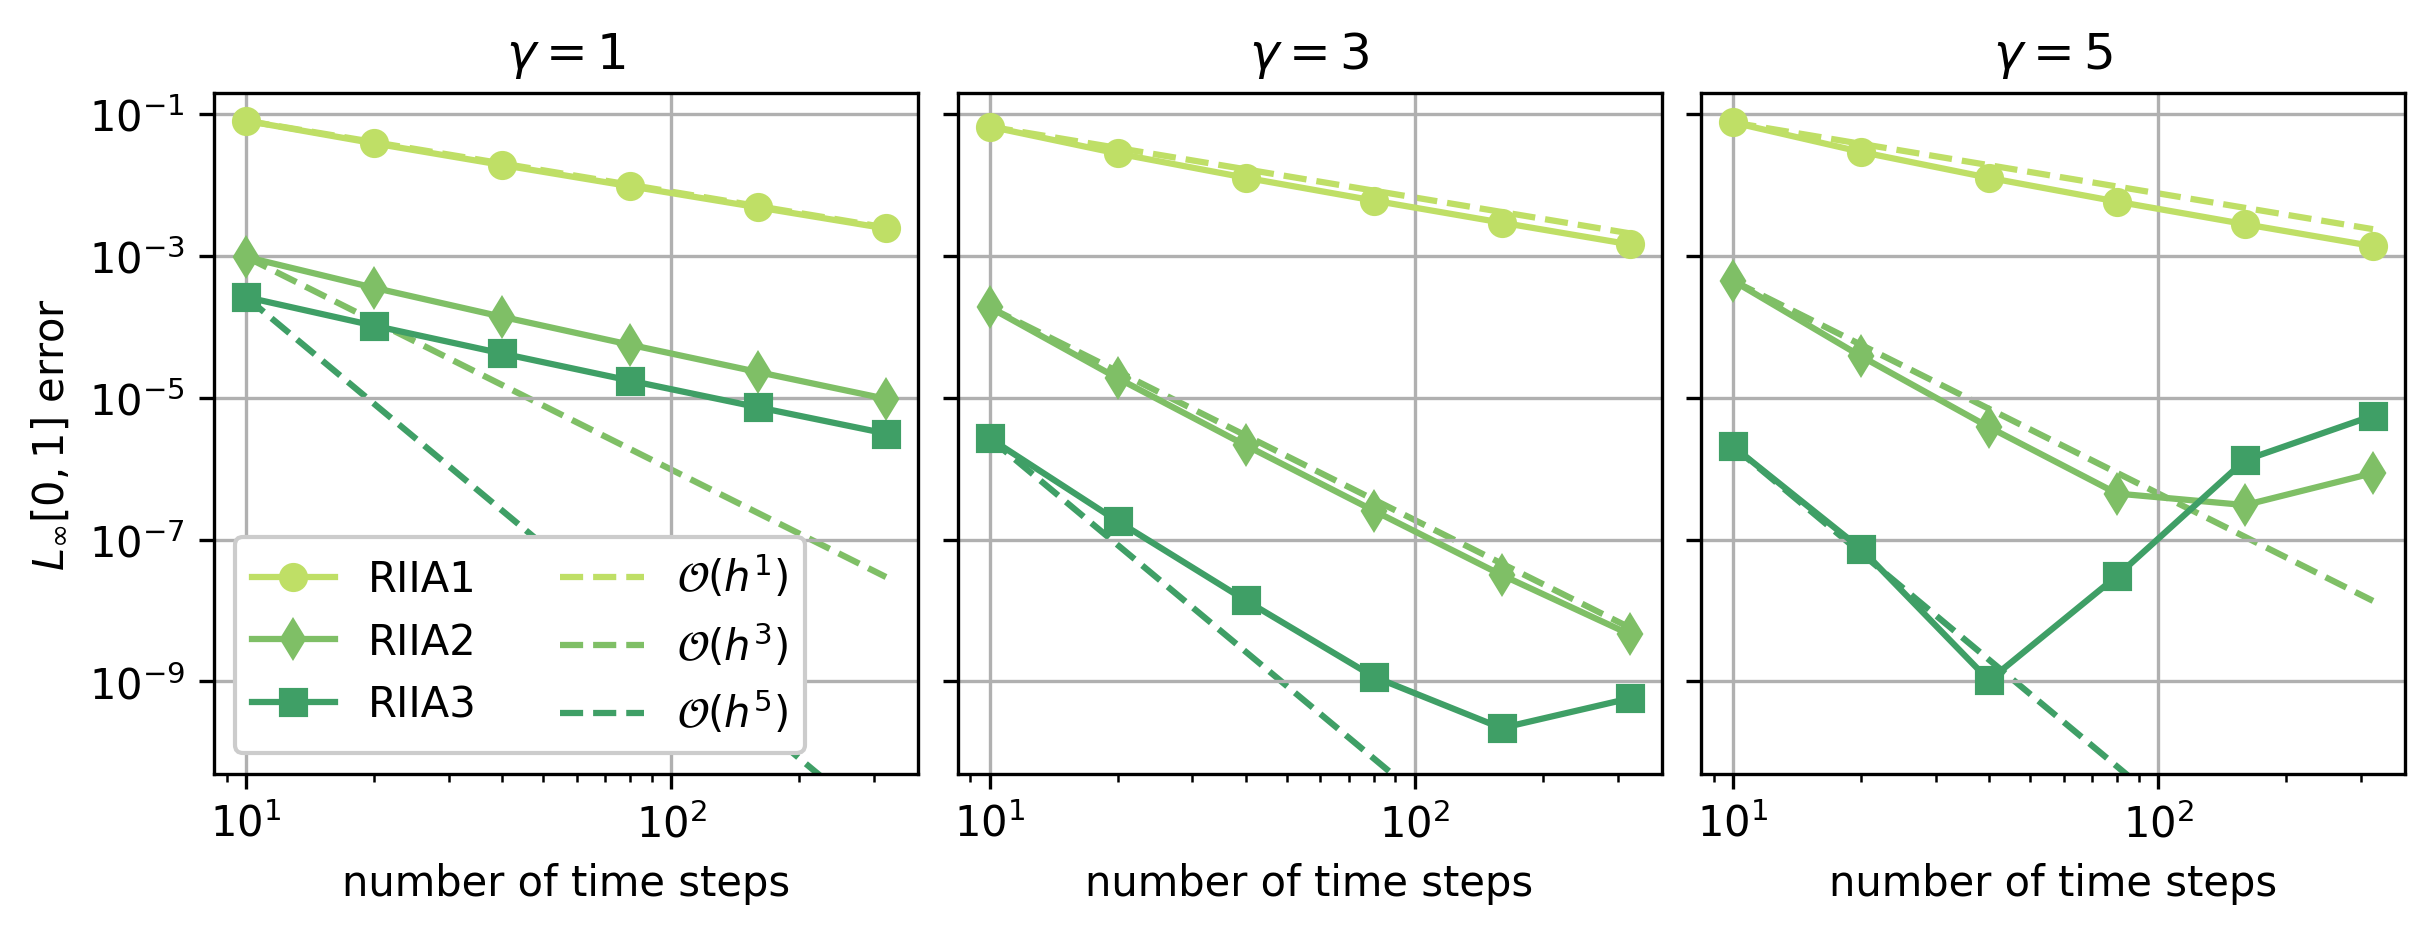

In [11]:
fig, ax = plt.subplots(1,3,figsize=(8,3), dpi=300, constrained_layout=True)    

cmap = plt.get_cmap("summer_r")

for idg, gamma in enumerate(gammas): 
    for idt, scheme in enumerate(schemes): 
        ax[idg].plot(Ns, Linferror_Ex2[scheme][gamma], label=scheme, marker=markers[scheme], color=cmap(1/4 + idt/4))

for idg, gamma in enumerate(gammas): 
    for idt, scheme in enumerate(schemes): 
        ax[idg].plot(Ns, Linferror_Ex2[scheme][gamma][0] * (Ns/Ns[0]) ** -orders[scheme], color=cmap(1/4 + idt/4), linestyle="--", label=ratelabels[scheme], zorder=-1)

for i in range(3): 
    ax[i].set_xlabel(r'number of time steps')
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    ax[i].set_ylim([5e-11,2e-1])
    ax[i].grid('on')
    ax[i].set_title(titles[i])

ax[0].set_ylabel(r"$L_\infty[0,1]$ error")
ax[0].legend(framealpha=1, loc="lower left", ncols=2)

ax[1].set_yticklabels([])
ax[2].set_yticklabels([])

fig.savefig("Images/Example2_nonzeroIC_graded.pdf", bbox_inches="tight")